# Question 3 - CNN

### Tevyn Vergara | 46421201 | Electrical & Biomedical Engineer

DISCLAIMER: Google Gemini 3 was used for this assignment for:
1. Layout tips (all questions)
2. Syntax checking (all questions)
3. Trouble shooting and debugging
4. Functionality tips and suggestions (all questions)
5. Tips and explanation for key functions/theories and purposes
6. Re-organizing to look more modular and readable

References:
1. Google. (2026, March 17). Methods of providing alterative text for accessibility on websites. [Generative AI chat]. Gemini 3. https://gemini.google.com/


## Standard Imports for Assignment 2 ##

Please run this before executing any other cell

In [11]:
import numpy as np
import pickle   
import matplotlib.pyplot as plt
import skimage
import sys
import time
import optuna

print('numpy', np.__version__)
print('matplotlib', plt.matplotlib.__version__)
print('skimage', skimage.__version__)
print('sys', sys.version)
print(sys.executable) 
print('pickle', pickle.format_version)
print(time.ctime())
print('optuna', optuna.__version__)

numpy 2.4.4
matplotlib 3.10.8
skimage 0.26.0
sys 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
c:\Users\tevyn\AppData\Local\Programs\Python\Python311\python.exe
pickle 4.0
Thu Apr 16 20:51:08 2026
optuna 4.8.0


c:\Users\tevyn\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## NOTE: Code was ran locally as I have a dedicated GPU ##

## Question "0" - CIFAR-10 Dataset ##

Here, I'm attempting to load the images. The formatting is currently:

- Labels in batches.meta [0-9] with their respective image classes:
    0: Aeroplane
    1: Automobile
    2: Bird
    3: Cat
    4: Deer
    5: Dog
    6: Frog
    7: Horse
    8: Ship
    9: Truck

- 3072 features of flattened information --> 32 x 32 pixel images with 3 RGB channels 

- 50,000 training images split into x5 data_batch_x files (5 in total). Format: shape(10,000, 3072). So 10,000 images per batch of 3072 flattened information

To format for CNN training:
1. Use unpickle() from source: https://www.cs.toronto.edu/~kriz/cifar.html. This returns a batch dictionary of the 10,000 images, their labels, and each of their single channel information of (32x32 | 3 RGB). Their is also metadata for the batch such as the image and batch file names (Not needed for project)

2. Unload image class labels from batches.meta (0-9) and convert their byte strings to normal text for readibility. Store in meta.

3. Unload and also combine the 5 batches of training data from data_batch_x where x: [0,5]. Assuming that all the images have the same format of 
(32x32 |3 RGB), append all imagee (with their data) and their respective labels to a dictionary of arrays that contain:
    - Image data (batch[b"data"])
    - Image labels (batch[b"data"])
    - Metadata (filenames, image names) but unused


To ensure that testing data was loaded correctly, loop through the whole "batch" dataset and load the first image of each class. Display it and its respective label.



C:\Users\tevyn\AppData\Local\Temp\ipykernel_14900\1026889439.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(fo, encoding="bytes")


X_train shape: (50000, 3072)
y_train shape: (50000,)
X_test shape: (10000, 3072)
y_test shape: (10000,)
Label names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


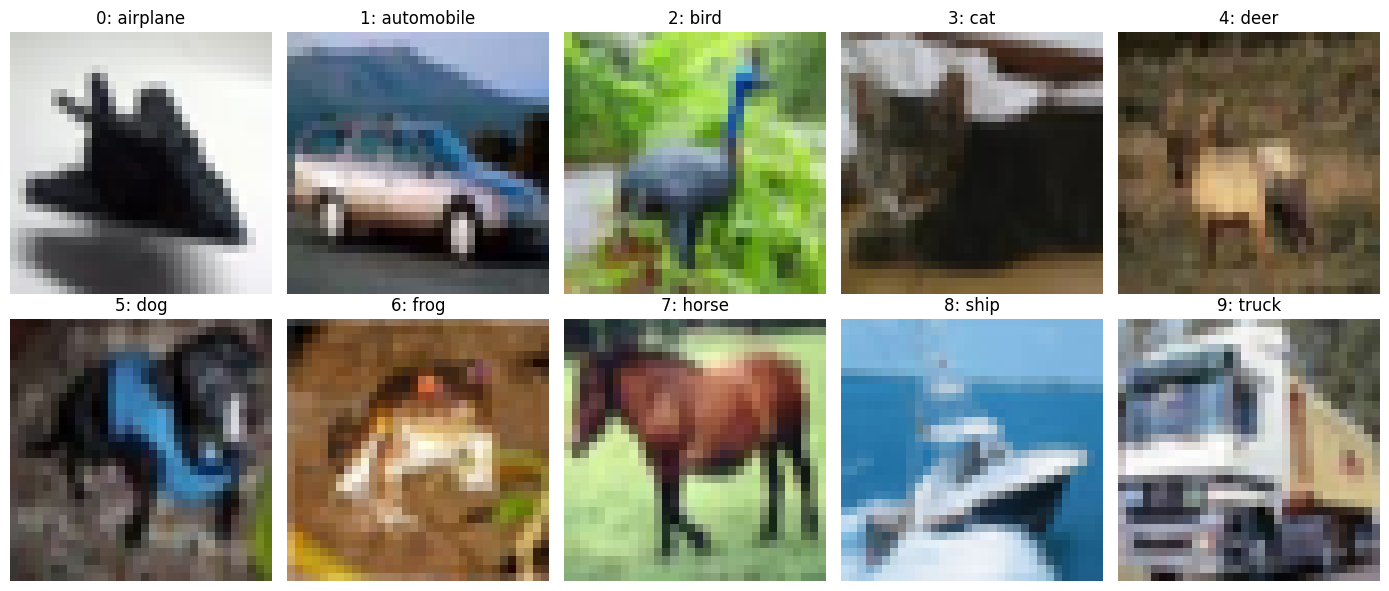

In [12]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt


# Utility: read one CIFAR-10 batch/metadata pickle file from disk. From: https://www.cs.toronto.edu/~kriz/cifar.html
def unpickle(file_path):
    with open(file_path, "rb") as fo:
        batch = pickle.load(fo, encoding="bytes")
    return batch

# End-to-end loader for CIFAR-10 in the provided folder structure.
# Returns train/test images + labels, and human-readable class names.
def load_cifar10(data):
    # 1) Load class label names (airplane, automobile, etc.) from metadata.
    meta = unpickle(os.path.join(data, "batches.meta"))
    label_names = [name.decode("utf-8") for name in meta[b"label_names"]]

    # 2) Read and concatenate all 5 training batch files.
    train_images = []
    train_labels = []
    for i in range(1, 6):
        batch = unpickle(os.path.join(data, f"data_batch_{i}"))
        train_images.append(batch[b"data"])
        train_labels.extend(batch[b"labels"])

    # 3) Stack image rows into one array of shape (50000, 3072).
    X_train = np.vstack(train_images)
    y_train = np.array(train_labels, dtype=np.int64)

    # 3) Load test batch
    test_batch = unpickle(os.path.join(data, "test_batch"))
    X_test = test_batch[b"data"]
    y_test = np.array(test_batch[b"labels"], dtype=np.int64)

    return X_train, y_train, X_test, y_test, label_names

# Load the CIFAR-10 Dataset 
data = "cifar-10-batches-py"
X_train, y_train, X_test, y_test, label_names = load_cifar10(data)

# Quick shape sanity check to confirm successful parsing.
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print("Label names:", label_names)

# Visual inspection: show one example image from each class.
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for class_id, ax in enumerate(axes.ravel()):
    # Pick the first training sample for this class index.
    idx = np.where(y_train == class_id)[0][0]
    img = X_train[idx].reshape(3, 32, 32).transpose(1, 2, 0)  # (3072,) -> (32,32,3)
    ax.imshow(img)
    ax.set_title(f"{class_id}: {label_names[class_id]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Formatting and Normalizing CIFAR-10 Dataset...


[I 2026-04-16 21:58:39,325] A new study created in memory with name: no-name-044d9843-a95e-407d-b13a-95e3905a854d



Starting Hyperparameter Optimization with Optuna (Subset of Data)...


[I 2026-04-16 21:58:43,030] Trial 0 finished with value: 2.301092362004982 and parameters: {'learning_rate': 0.026998783801703088, 'num_filters': 9, 'epochs': 5}. Best is trial 0 with value: 2.301092362004982.
[I 2026-04-16 21:58:49,794] Trial 1 finished with value: 2.301473217794986 and parameters: {'learning_rate': 0.005373842931182791, 'num_filters': 7, 'epochs': 10}. Best is trial 0 with value: 2.301092362004982.
[I 2026-04-16 21:58:55,715] Trial 2 finished with value: 2.300605298739552 and parameters: {'learning_rate': 0.09282088209477123, 'num_filters': 11, 'epochs': 7}. Best is trial 2 with value: 2.300605298739552.
[I 2026-04-16 21:59:00,840] Trial 3 finished with value: 2.29430984682261 and parameters: {'learning_rate': 0.06032922462738256, 'num_filters': 8, 'epochs': 8}. Best is trial 3 with value: 2.29430984682261.
[I 2026-04-16 21:59:02,293] Trial 4 finished with value: 2.3000723964905325 and parameters: {'learning_rate': 0.0593631047469431, 'num_filters': 5, 'epochs': 3}. 


Optimized Parameters Found:
  learning_rate: 0.06032922462738256
  num_filters: 8
  epochs: 8

--- Building & Training CNN: 8 Filters | LR: 0.0603 ---
  Epoch 1/8 | Loss: 2.2819
  Epoch 2/8 | Loss: 2.1979
  Epoch 3/8 | Loss: 2.1296
  Epoch 4/8 | Loss: 2.2278
  Epoch 5/8 | Loss: 2.1963
  Epoch 6/8 | Loss: 2.1217
  Epoch 7/8 | Loss: 2.0866
  Epoch 8/8 | Loss: 2.0874

Total Training Time (5000 samples): 0.52 minutes

Evaluating Model on 10,000 Test Images...
Overall Testing Accuracy: 28.76%

--- Accuracy Split by Class ---
  Airplane: 49.30%
  Automobile: 31.00%
  Bird: 5.40%
  Cat: 3.90%
  Deer: 48.30%
  Dog: 38.80%
  Frog: 19.80%
  Horse: 22.30%
  Ship: 14.60%
  Truck: 54.20%

Final Epoch Loss: 2.0873601525286367


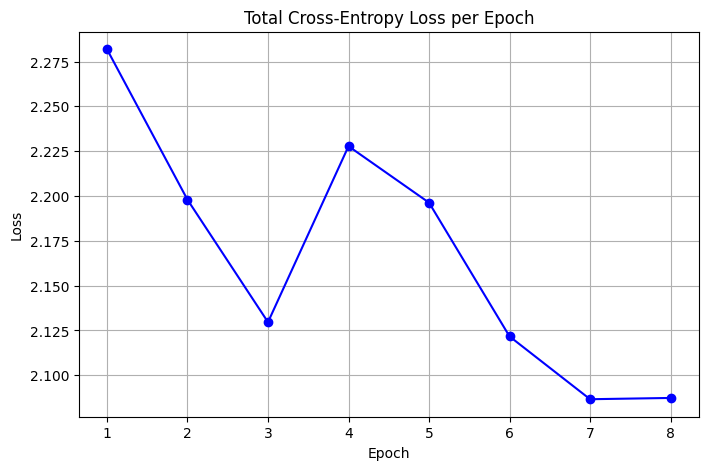

In [18]:
# ---------------------------------------------------------
# IMPORT STANDARD LIBRARIES & OPTUNA
# ---------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import time
import optuna

# =========================================================
# DATA PREPARATION (Using your loaded CIFAR-10 data)
# =========================================================
print("Formatting and Normalizing CIFAR-10 Dataset...")

# Normalize pixel values to a [0, 1] range to prevent gradient explosions
X_train_norm = X_train.astype(np.float32) / 255.0
X_test_norm = X_test.astype(np.float32) / 255.0

# KEY CONCEPT 1: Vectorize (flatten/reshape) images
# Convert from flat 3072 features to (Batch, Channels, Height, Width)
X_train_reshaped = X_train_norm.reshape(-1, 3, 32, 32)
X_test_reshaped = X_test_norm.reshape(-1, 3, 32, 32)

def one_hot_encode(Y, num_classes=10):
    """Converts categorical labels (0-9) to one-hot encoded vectors."""
    Y_one_hot = np.zeros((Y.shape[0], num_classes))
    Y_one_hot[np.arange(Y.shape[0]), Y] = 1
    return Y_one_hot

Y_train_one_hot = one_hot_encode(y_train)
Y_test_one_hot = one_hot_encode(y_test)

# =========================================================
# KEY CONCEPT 6: Convolution Layer + Activation Maps
# =========================================================
def conv_forward(X, W1, b1, stride=1, padding=1):
    """
    Vectorized forward pass for Convolutional Layer.
    Uses np.tensordot to eliminate slow Python batch/filter loops.
    """
    n_x, c_x, h_x, w_x = X.shape
    n_f, c_f, f_h, f_w = W1.shape
    
    out_h = int((h_x + 2 * padding - f_h) / stride) + 1
    out_w = int((w_x + 2 * padding - f_w) / stride) + 1
    
    X_padded = np.pad(X, ((0,0), (0,0), (padding, padding), (padding, padding)), mode='constant')
    out = np.zeros((n_x, n_f, out_h, out_w))
    
    # Slide the filter window across the height and width of the image
    for h in range(out_h):
        for w in range(out_w):
            h_start, w_start = h * stride, w * stride
            window = X_padded[:, :, h_start:h_start+f_h, w_start:w_start+f_w]
            
            # Element-wise multiplication & sum across all batches and channels simultaneously
            out[:, :, h, w] = np.tensordot(window, W1, axes=([1,2,3], [1,2,3])) + b1
            
    return out, X_padded

# =========================================================
# KEY CONCEPT 2: Non-linear score function & activation
# =========================================================
def relu(Z):
    return np.maximum(0, Z)

def relu_backward(dZ, Z):
    dZ_out = np.array(dZ, copy=True)
    dZ_out[Z <= 0] = 0
    return dZ_out

def softmax(Z):
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True) # Shift for numerical stability
    exp_Z = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

# =========================================================
# KEY CONCEPT 3: Loss Function
# =========================================================
def compute_loss(Y_pred, Y_true):
    n_samples = Y_true.shape[0]
    Y_pred_clipped = np.clip(Y_pred, 1e-12, 1.0)
    return -np.sum(Y_true * np.log(Y_pred_clipped)) / n_samples

# =========================================================
# KEY CONCEPT 4 & 5: Total Loss & Gradient Updates
# =========================================================
def train_step(X_batch, Y_batch, W1, b1, W2, b2, learning_rate):
    n_samples = X_batch.shape[0]
    
    # --- FORWARD PASS ---
    Z1, X_padded = conv_forward(X_batch, W1, b1)
    A1 = relu(Z1)
    
    # Flatten activation maps for the Dense output layer
    A1_flat = A1.reshape(n_samples, -1) 
    Z2 = np.dot(A1_flat, W2.T) + b2.T
    Y_pred = softmax(Z2)
    loss = compute_loss(Y_pred, Y_batch)
    
    # --- BACKWARD PASS ---
    dZ2 = Y_pred - Y_batch 
    dW2 = np.dot(dZ2.T, A1_flat) / n_samples
    db2 = np.sum(dZ2, axis=0, keepdims=True).T / n_samples
    
    dA1_flat = np.dot(dZ2, W2)
    dA1 = dA1_flat.reshape(A1.shape)
    dZ1 = relu_backward(dA1, Z1)
    
    # Vectorized convolution gradient calculation
    dW1 = np.zeros_like(W1)
    db1 = np.sum(dZ1, axis=(0, 2, 3)) / n_samples
    n_f, c_f, f_h, f_w = W1.shape
    out_h, out_w = dZ1.shape[2], dZ1.shape[3]
    
    for h in range(f_h):
        for w in range(f_w):
            window = X_padded[:, :, h:h+out_h, w:w+out_w]
            dW1[:, :, h, w] = np.tensordot(dZ1, window, axes=([0,2,3], [0,2,3])) / n_samples
            
    # --- UPDATE WEIGHTS ---
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    
    return loss, W1, b1, W2, b2

# =========================================================
# MODEL TRAINING & PREDICTION FUNCTIONS
# =========================================================
def fit_model(X, Y, num_filters, learning_rate, epochs, batch_size=256):
    """Trains the CNN on full batches and returns weights and history."""
    print(f"\n--- Building & Training CNN: {num_filters} Filters | LR: {learning_rate:.4f} ---")
    start_time = time.time()
    n_samples = X.shape[0]
    
    # Initialize weights
    W1 = np.random.randn(num_filters, 3, 3, 3) * 0.01
    b1 = np.zeros(num_filters)
    flattened_size = num_filters * 32 * 32
    W2 = np.random.randn(10, flattened_size) * 0.01
    b2 = np.zeros((10, 1))
    
    epoch_losses = []
    
    for epoch in range(epochs):
        # Prevent Data Leakage/Overfitting by shuffling the training data every epoch
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        X_shuffled, Y_shuffled = X[indices], Y[indices]
        
        batch_losses = []
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            Y_batch = Y_shuffled[i:i+batch_size]
            
            loss, W1, b1, W2, b2 = train_step(X_batch, Y_batch, W1, b1, W2, b2, learning_rate)
            batch_losses.append(loss)
            
        epoch_loss = np.mean(batch_losses)
        epoch_losses.append(epoch_loss)
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f}")
        
    train_time = time.time() - start_time
    return W1, b1, W2, b2, epoch_losses, train_time

def predict(X, W1, b1, W2, b2, batch_size=256):
    """Generates predictions for an entire dataset in manageable batches."""
    n_samples = X.shape[0]
    predictions = []
    for i in range(0, n_samples, batch_size):
        X_batch = X[i:i+batch_size]
        Z1, _ = conv_forward(X_batch, W1, b1)
        A1_flat = relu(Z1).reshape(X_batch.shape[0], -1)
        Z2 = np.dot(A1_flat, W2.T) + b2.T
        predictions.append(np.argmax(softmax(Z2), axis=1))
    return np.concatenate(predictions)

# =========================================================
# OPTUNA OBJECTIVE FUNCTION
# =========================================================
def objective(trial):
    # Search spaces
    lr = trial.suggest_float("learning_rate", 1e-3, 1e-1, log=True)
    num_filters = trial.suggest_int("num_filters", 4, 12) 
    epochs = trial.suggest_int("epochs", 3, 10)
    
    # Use a small subset (1000 images) so hyperparameter searching doesn't take 5 hours
    subset_idx = np.random.choice(len(X_train_reshaped), 1000, replace=False)
    X_sub, Y_sub = X_train_reshaped[subset_idx], Y_train_one_hot[subset_idx]
    
    W1 = np.random.randn(num_filters, 3, 3, 3) * 0.01
    b1 = np.zeros(num_filters)
    W2 = np.random.randn(10, num_filters * 32 * 32) * 0.01
    b2 = np.zeros((10, 1))
    
    for epoch in range(epochs):
        loss, W1, b1, W2, b2 = train_step(X_sub, Y_sub, W1, b1, W2, b2, lr)
        trial.report(loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
            
    return loss

# =========================================================
# EXECUTION (Train -> Evaluate -> Plot)
# =========================================================
if __name__ == "__main__":
    # 1 & 2. Optimize Hyperparameters
    print("\nStarting Hyperparameter Optimization with Optuna (Subset of Data)...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=5) 
    
    best_params = study.best_trial.params
    print("\nOptimized Parameters Found:")
    for k, v in best_params.items():
        print(f"  {k}: {v}")

    # 3. Fully Build & Train the CNN using best hyperparameters
    # Note: To save execution time locally, we use a 5000 image subset. 
    # Change [0:5000] to [:] to run the full 50,000 dataset.
    TRAIN_SIZE = 5000 
    W1, b1, W2, b2, epoch_losses, train_time = fit_model(
        X_train_reshaped[0:TRAIN_SIZE], 
        Y_train_one_hot[0:TRAIN_SIZE], 
        num_filters=best_params["num_filters"], 
        learning_rate=best_params["learning_rate"], 
        epochs=best_params["epochs"]
    )

    # 4. Report Training Time & Testing Accuracy
    print(f"\nTotal Training Time ({TRAIN_SIZE} samples): {train_time/60:.2f} minutes")
    
    print("\nEvaluating Model on 10,000 Test Images...")
    y_pred = predict(X_test_reshaped, W1, b1, W2, b2)
    
    overall_acc = np.mean(y_pred == y_test) * 100
    print(f"Overall Testing Accuracy: {overall_acc:.2f}%\n")
    
    print("--- Accuracy Split by Class ---")
    for i, class_name in enumerate(label_names):
        class_idx = np.where(y_test == i)[0]
        class_acc = np.mean(y_pred[class_idx] == y_test[class_idx]) * 100
        print(f"  {class_name.capitalize()}: {class_acc:.2f}%")

    # 5. Report and display epoch loss
    print("\nFinal Epoch Loss:", epoch_losses[-1])
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(epoch_losses)+1), epoch_losses, marker='o', linestyle='-', color='b')
    plt.title("Total Cross-Entropy Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

In [ ]:
# RESULTS: HOG Feature Extraction Version #

Things to tweak to improve testing accuracy (LBP):
1. Number of epochs: Increasing epochs may allow the model to learn more complex patterns, but watch for overfitting.
2. Learning rate: Adjusting the learning rate can help the model converge better. Too high may cause divergence, too low may slow down training.
3. Batch size: Experimenting with different batch sizes (e.g., 128, 512) can affect convergence and generalization.
4. Feature extraction parameters: Tuning HOG parameters (orientations, pixels_per_cell, cells_per_block) may yield more discriminative features.

NameError: name 'params' is not defined

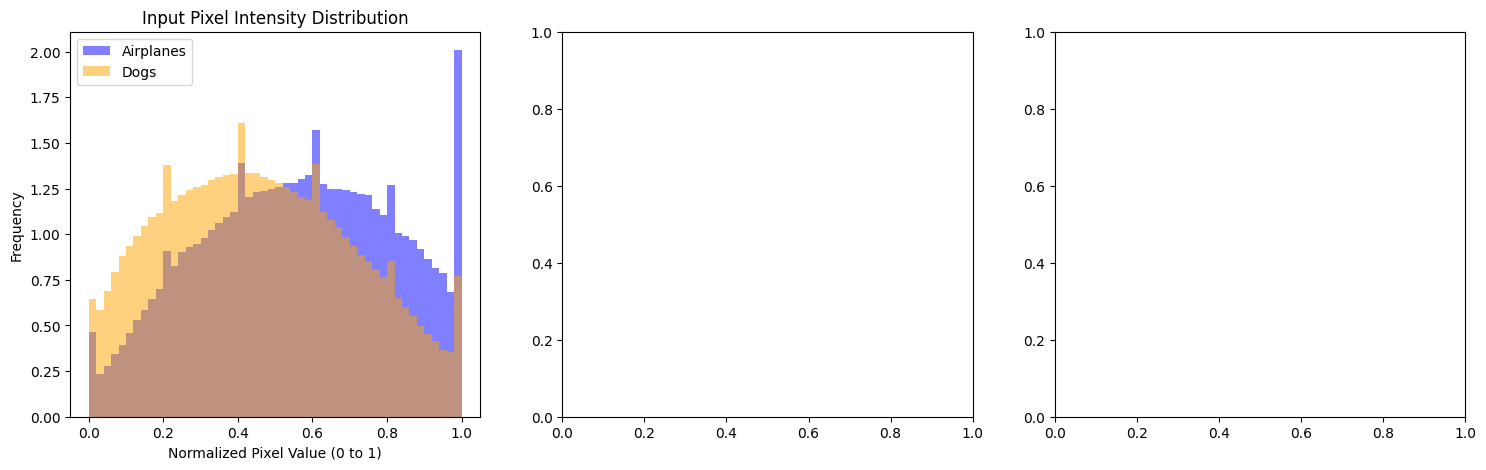

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------------
# 1. Input Feature Distribution (Pixel Intensities)
# ---------------------------------------------------------
# Let's compare Class 0 (Airplane) and Class 5 (Dog)
airplanes = X_train_norm[y_train == 0].flatten()
dogs = X_train_norm[y_train == 5].flatten()

axes[0].hist(airplanes, bins=50, alpha=0.5, color='blue', label='Airplanes', density=True)
axes[0].hist(dogs, bins=50, alpha=0.5, color='orange', label='Dogs', density=True)
axes[0].set_title("Input Pixel Intensity Distribution")
axes[0].set_xlabel("Normalized Pixel Value (0 to 1)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# ---------------------------------------------------------
# 2. Network Weight Distribution (W1 & W2)
# ---------------------------------------------------------
# Flatten the weight matrices from your trained params dictionary
w1_flat = params['W1'].flatten()
w2_flat = params['W2'].flatten()

axes[1].hist(w1_flat, bins=50, alpha=0.6, color='purple', label='Conv W1', density=True)
axes[1].hist(w2_flat, bins=50, alpha=0.6, color='green', label='Dense W2', density=True)
axes[1].set_title("Trained Weight Matrix Distribution")
axes[1].set_xlabel("Weight Value")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# ---------------------------------------------------------
# 3. Activation Distribution (Checking for Dead ReLUs)
# ---------------------------------------------------------
# Pass a single batch through the first layer to see how the ReLU reacts
X_sample = X_test_reshaped[0:128] # Take one batch
Z1, _ = conv_forward(X_sample, params['W1'], params['b1'])
A1 = relu(Z1) # Apply Activation

axes[2].hist(A1.flatten(), bins=50, color='red')
axes[2].set_title("ReLU Activation Distribution (A1)")
axes[2].set_xlabel("Activation Value")
axes[2].set_ylabel("Frequency")
# Add a line to emphasize the zero-values (Dead ReLUs)
zero_count = np.sum(A1.flatten() == 0)
total_count = len(A1.flatten())
axes[2].text(0.5, 0.8, f"Zeros (Dead): {zero_count/total_count*100:.1f}%", 
             transform=axes[2].transAxes, fontsize=12, color='darkred', weight='bold')

plt.tight_layout()
plt.show()